In [19]:
from pathlib import Path
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

from mis_dro.bayes_conjugates import *
from mis_dro.likelihood import *
from mis_dro.dataset import *
from mis_dro.portfolio import bdro_portfolio_posterior_samples

In [20]:
dgp = "DowJones"
replication = 0
data, data_eval = portfolio_dataset(dgp, replication, Path("/dcs/pg20/u1508153/datasets/misdro/mmc2"))
num_observations = data.shape[0]
dim = data.shape[1]

In [21]:
generator = np.random.default_rng(replication)
posterior = "normal_inverse_wishart"
theta_prior = default_prior_params("normal_inverse_wishart", dim=dim)
theta_posterior = get_posterior_params(posterior, data, theta_prior)
mu_prior, kappa_prior, iota_prior, Psi_prior = theta_prior
mu_post, kappa_post, iota_post, Psi_post = theta_posterior
assert iota_post == kappa_post - dim - 2

# Sample from the prior

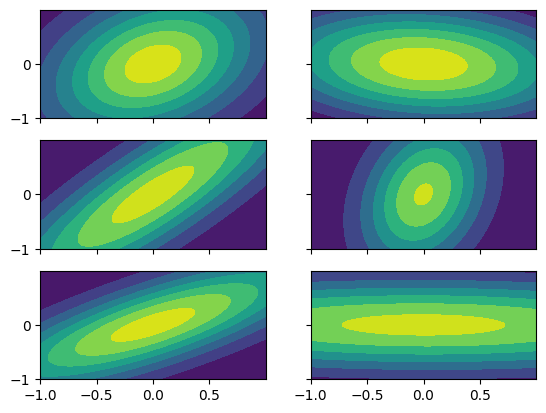

In [22]:
num_prior_samples = 6
theta_sample = bdro_portfolio_posterior_samples(num_prior_samples, mu_prior, iota_prior, Psi_prior, generator=generator)
mu_prior_samples = theta_sample[:, :dim]
cov_prior_samples = np.zeros((num_prior_samples, dim, dim))
for i in range(num_prior_samples):
    cov_prior_samples[i] = reconstruct_covariance_from_triu(theta_sample[i,dim:], dim)

axis1, axis2 = np.mgrid[-1:1:0.001, -1:1:0.001]
fig, axes = plt.subplots(nrows=int(np.ceil(num_prior_samples/2)), ncols=2, sharex=True, sharey=True)
for i, (mu, cov) in enumerate(zip(mu_prior_samples, cov_prior_samples)):
    if i >= num_prior_samples:
        break
    axes[int(i/ 2)][i%2].contourf(axis1, axis2, sp.stats.multivariate_normal(mu[:2], cov[:2,:2], seed=generator).pdf(np.dstack((axis1, axis2))))



### Sample from the posterior - visualise first two dimensions

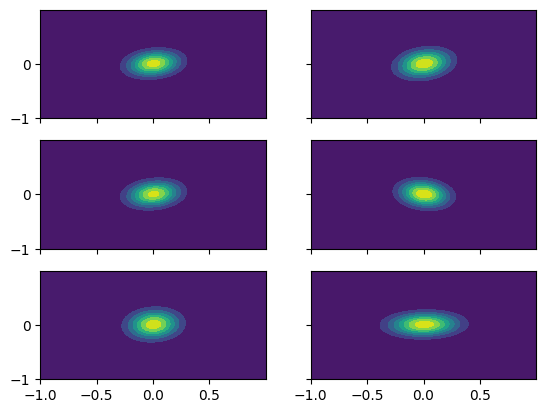

In [24]:
num_posterior_samples = 6
theta_sample = bdro_portfolio_posterior_samples(num_posterior_samples, mu_post, iota_post, Psi_post, generator=generator)
mu_posterior_samples = theta_sample[:, :dim]
cov_posterior_samples = np.zeros((num_posterior_samples, dim, dim))
for i in range(num_posterior_samples):
    cov_posterior_samples[i] = reconstruct_covariance_from_triu(theta_sample[i,dim:], dim)

axis1, axis2 = np.mgrid[-1:1:0.001, -1:1:0.001]
fig, axes = plt.subplots(nrows=int(np.ceil(num_posterior_samples/2)), ncols=2, sharex=True, sharey=True)
for i, (mu, cov) in enumerate(zip(mu_posterior_samples, cov_posterior_samples)):
    if i >= num_posterior_samples:
        break
    axes[int(i/ 2)][i%2].contourf(axis1, axis2, sp.stats.multivariate_normal(mu[:2], cov[:2,:2], seed=generator).pdf(np.dstack((axis1, axis2))))



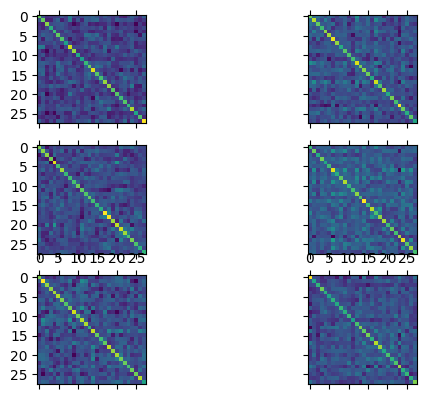

In [39]:
cov_posterior_samples
fig, axes = plt.subplots(nrows=int(np.ceil(num_posterior_samples/2)), ncols=2, sharex=True, sharey=True)
for i, (mu, cov) in enumerate(zip(mu_posterior_samples, cov_posterior_samples)):
    if i >= num_posterior_samples:
        break
    axes[int(i/ 2)][i%2].matshow(cov)
    # plt.colorbar(ax=axes[int(i/ 2)][i%2])


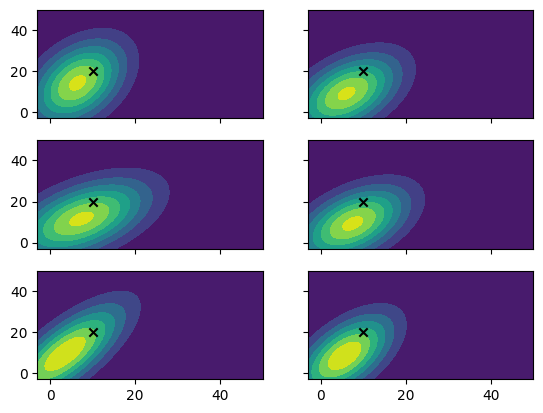

In [9]:
post_mu_samples, post_cov_samples = normal_inverse_wishart_samples(num_posterior_samples, *theta_posterior, generator=generator)
axis1, axis2 = np.mgrid[-3:50:0.1, -3:50:0.1]
fig, axes = plt.subplots(nrows=int(np.ceil(max_samples/2)), ncols=2, sharex=True, sharey=True)
for i, (mu, cov) in enumerate(zip(post_mu_samples, post_cov_samples)):
    if i >= max_samples:
        break
    axes[int(i/ 2)][i%2].contourf(axis1, axis2, sp.stats.multivariate_normal(mu[:2], cov[:2,:2], seed=generator).pdf(np.dstack((axis1, axis2))))
    axes[int(i/ 2)][i%2].scatter(dgp_mean[0], dgp_mean[1], marker="x", color="black")

/var/folders/38/gm_d4yxj7bx11rp4p930zwnr0000gn/T/ipykernel_4019/2424180084.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


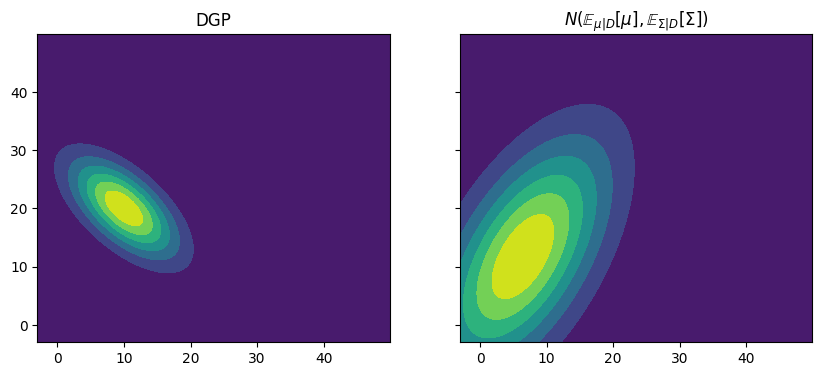

In [10]:
# plot expected Sigma next to DGP
fig, (ax1, ax2) = plt.subplots(ncols=2, sharex=True, sharey=True, figsize=(10,4))
expected_Sigma = Psi_post / (iota_post - Psi_post.shape[0] - 1)
dgp_dist = sp.stats.multivariate_normal(dgp_mean[:2], dgp_cov[:2,:2], seed=generator)
ax1.contourf(axis1, axis2, dgp_dist.pdf(np.dstack((axis1,axis2))))
ax1.set_title("DGP")
# ax2.contourf(axis1, axis2, sp.stats.multivariate_normal(post_mu_samples[0], post_cov_samples[0], seed=generator).pdf(np.dstack((axis1,axis2))))
ax2.contourf(axis1, axis2, sp.stats.multivariate_normal(mu_post[:2], expected_Sigma[:2,:2], seed=generator).pdf(np.dstack((axis1,axis2))))
ax2.set_title(r"$N(\mathbb{E}_{\mu | D}[\mu], \mathbb{E}_{\Sigma | D}[\Sigma])$")
fig.show()

In [30]:
dgp_mean = np.mean(data, axis=0)
dgp_cov = np.cov(data.T)
dgp_mean.shape, dgp_cov.shape

((28,), (28, 28))

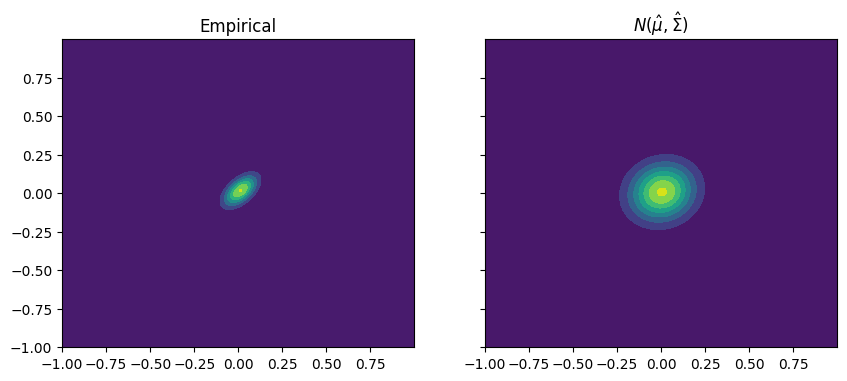

In [34]:
# plot hat{Sigma} next to the DGP
fig, (ax1, ax2) = plt.subplots(ncols=2, sharex=True, sharey=True, figsize=(10,4))

params = derive_analytical_posterior_params("normal_inverse_wishart", theta_posterior)
mu_hat = params[0, :dim]
Sigma_hat = reconstruct_covariance_from_triu(params[0, dim:], dim)

dgp_dist = sp.stats.multivariate_normal(dgp_mean[:2], dgp_cov[:2,:2], seed=generator)
ax1.contourf(axis1, axis2, dgp_dist.pdf(np.dstack((axis1,axis2))))
ax1.set_title("Empirical")
# ax2.contourf(axis1, axis2, sp.stats.multivariate_normal(post_mu_samples[0], post_cov_samples[0], seed=generator).pdf(np.dstack((axis1,axis2))))
ax2.contourf(axis1, axis2, sp.stats.multivariate_normal(mu_hat[:2], Sigma_hat[:2,:2], seed=generator).pdf(np.dstack((axis1,axis2))))
ax2.set_title(r"$N(\hat{\mu}, \hat{\Sigma})$")
fig.show()

/var/folders/38/gm_d4yxj7bx11rp4p930zwnr0000gn/T/ipykernel_4019/4102054644.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


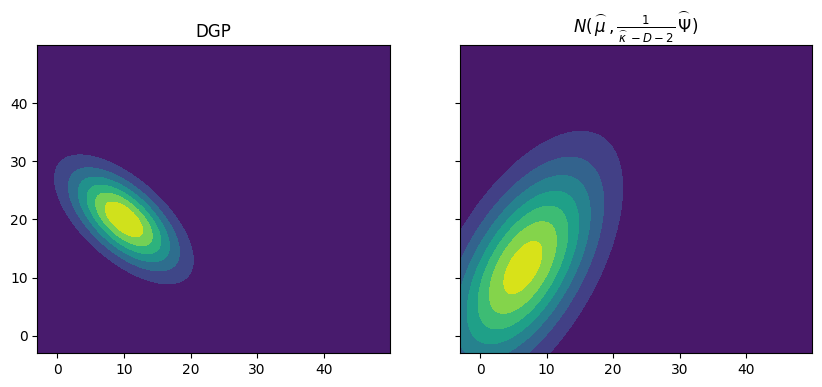

In [18]:
fig, (ax1, ax2) = plt.subplots(ncols=2, sharex=True, sharey=True, figsize=(10,4))

Sigma_hat = (1/(kappa_post - dim - 2))*Psi_post
# Sigma_hat = (1/(iota_post))*Psi_post

mu_hat =  mu_post

dgp_dist = sp.stats.multivariate_normal(dgp_mean[:2], dgp_cov[:2,:2], seed=generator)
ax1.contourf(axis1, axis2, dgp_dist.pdf(np.dstack((axis1,axis2))))
ax1.set_title("DGP")
# ax2.contourf(axis1, axis2, sp.stats.multivariate_normal(post_mu_samples[0], post_cov_samples[0], seed=generator).pdf(np.dstack((axis1,axis2))))
ax2.contourf(axis1, axis2, sp.stats.multivariate_normal(mu_hat[:2], Sigma_hat[:2,:2], seed=generator).pdf(np.dstack((axis1,axis2))))
ax2.set_title(r"$N(\overset{\frown}{\mu}, \frac{1}{\overset{\frown}{\kappa} - D - 2} \overset{\frown}{\Psi})$")
fig.show()

/var/folders/38/gm_d4yxj7bx11rp4p930zwnr0000gn/T/ipykernel_48086/169037416.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


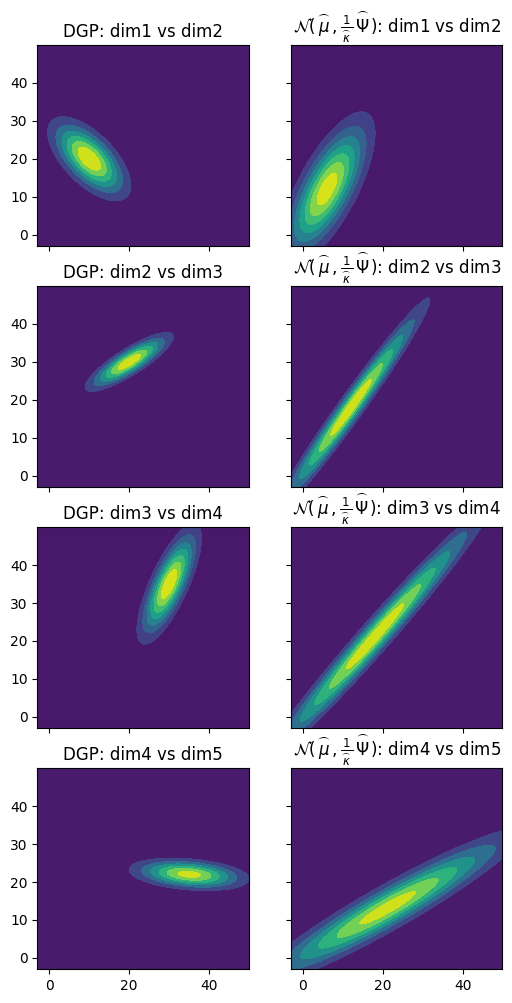

In [ ]:
# visualise slices of the DGP
fig, axes = plt.subplots(ncols=2, nrows=dim-1, sharex=True, sharey=True, figsize=(6,12))
for d in range(dim-1):
    dgp_dist = sp.stats.multivariate_normal(dgp_mean[d:d+2], dgp_cov[d:d+2,d:d+2])
    axes[d][0].contourf(axis1, axis2, dgp_dist.pdf(np.dstack((axis1,axis2))))
    axes[d][0].set_title(f"DGP: dim{d+1} vs dim{d+2}")
    sad_dist = sp.stats.multivariate_normal(mu_hat[d:d+2], Sigma_hat[d:d+2,d:d+2], seed=generator)
    axes[d][1].contourf(axis1, axis2, sad_dist.pdf(np.dstack((axis1,axis2))))
    axes[d][1].set_title(r"$\mathcal{N}(\overset{\frown}{\mu}, \frac{1}{\overset{\frown}{\kappa}} \overset{\frown}{\Psi})$: " + f"dim{d+1} vs dim{d+2}")
fig.show()